In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

305534    107500.0
496803     60000.0
481050    105000.0
18728     164746.0
431577     70000.0
771028     98800.0
278108    125000.0
203094     74000.0
157047    200000.0
53874     115000.0
Name: salary_year_avg, dtype: float64

<Axes: >

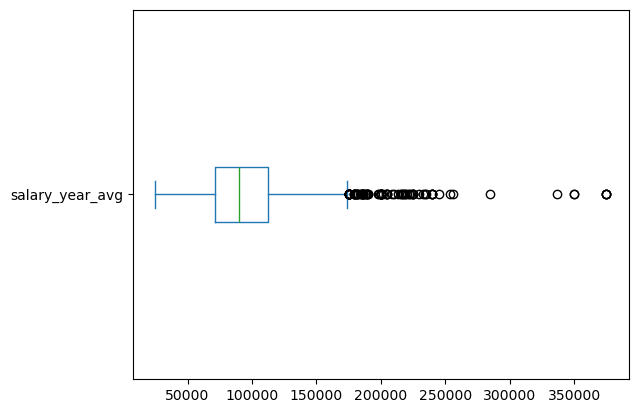

In [6]:
df_DA_US['salary_year_avg'].plot(kind = 'box', vert = False)

{'whiskers': [<matplotlib.lines.Line2D at 0x17966740bd0>,
 'caps': [<matplotlib.lines.Line2D at 0x17966741f10>,
 'boxes': [<matplotlib.lines.Line2D at 0x17966cdbf10>],
 'medians': [<matplotlib.lines.Line2D at 0x17966743190>],
 'fliers': [<matplotlib.lines.Line2D at 0x179667439d0>],
 'means': []}

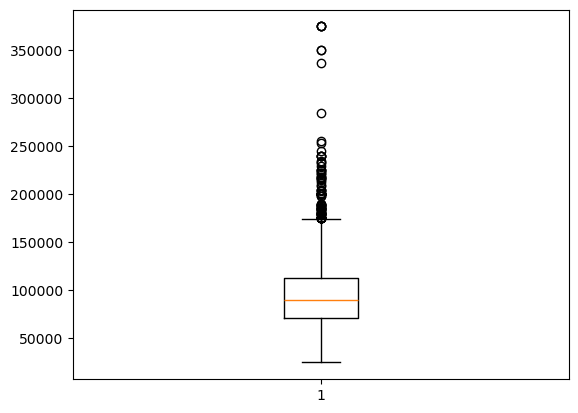

In [5]:
plt.boxplot(df_DA_US['salary_year_avg'])

C:\Users\yhk25\AppData\Local\Temp\ipykernel_21116\1556140524.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels = job_titles, vert = False)


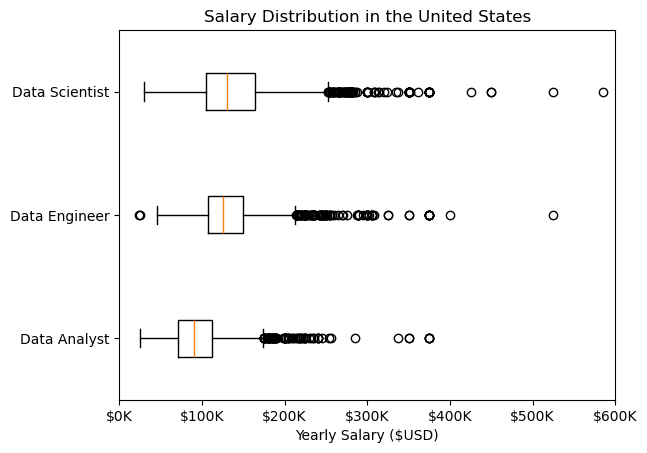

In [17]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset = ['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels = job_titles, vert = False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.xlim(0, 600000)
plt.show()

## Again

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

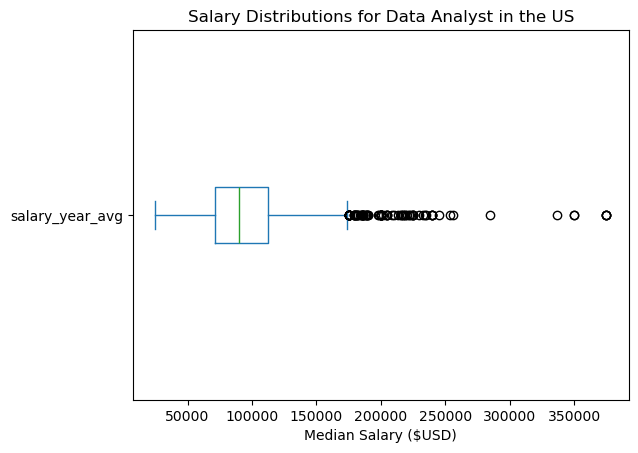

In [6]:
df_DA_US['salary_year_avg'].plot(kind = 'box', vert = False)
plt.title('Salary Distributions for Data Analyst in the US')
plt.xlabel('Median Salary ($USD)')
plt.show()

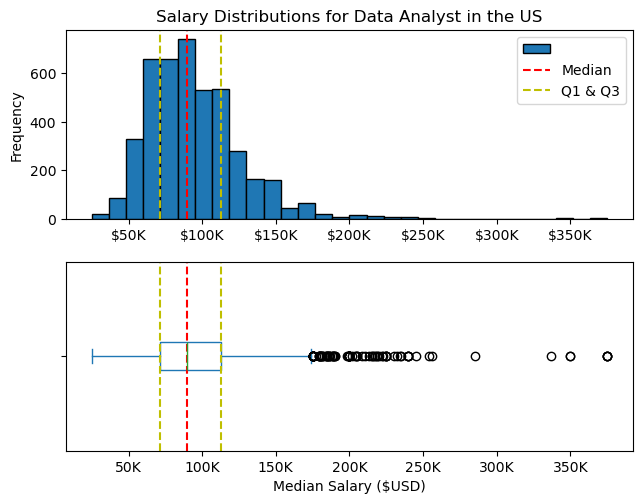

In [19]:
fig, ax = plt.subplots(2, 1)
fig.tight_layout(h_pad = 1)

df_DA_US['salary_year_avg'].plot(kind = 'hist', ax = ax[0], bins = 30, edgecolor = 'black')
ax[0].set_title('Salary Distributions for Data Analyst in the US')
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, post: f'${int(x/1000)}K'))
ax[0].axvline(df_DA_US['salary_year_avg'].median(), color='r', linestyle='--')
ax[0].axvline(df_DA_US['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[0].axvline(df_DA_US['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
ax[0].legend(['', 'Median', 'Q1 & Q3'])

df_DA_US['salary_year_avg'].plot(kind = 'box', ax = ax[1], vert = False)
ax[1].set_yticklabels('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))
ax[1].axvline(df_DA_US['salary_year_avg'].median(), color = 'r', linestyle = '--')
ax[1].axvline(df_DA_US['salary_year_avg'].quantile(0.25), color = 'y', linestyle = '--')
ax[1].axvline(df_DA_US['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
plt.show()

In [20]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset = ['salary_year_avg'])

C:\Users\yhk25\AppData\Local\Temp\ipykernel_14792\4086892584.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels = job_titles, vert = False)


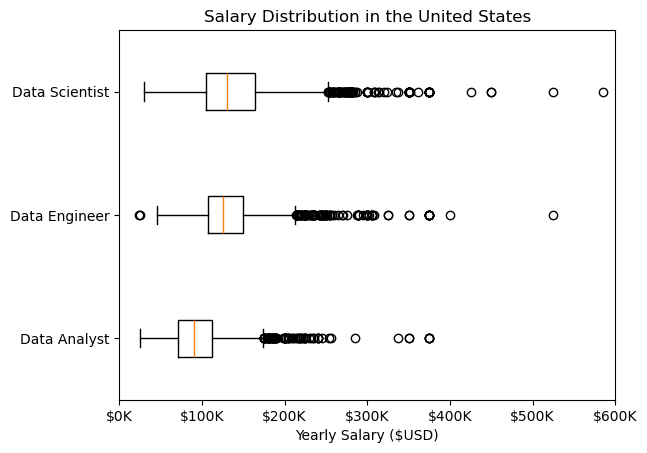

In [22]:
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels = job_titles, vert = False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

plt.xlim(0, 600000) 

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

## Probem

In [6]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


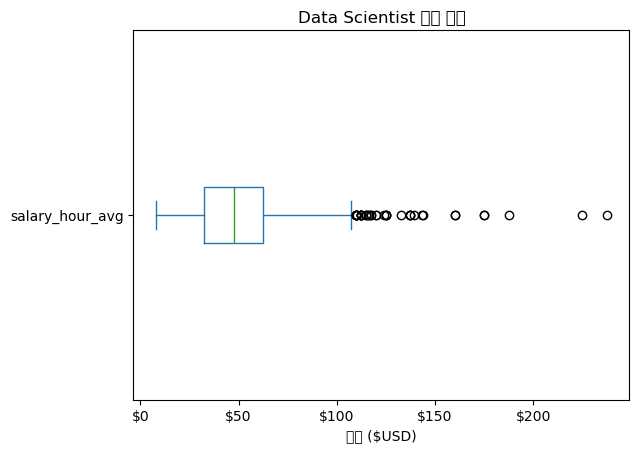

In [13]:
# ===== 데이터 필터링 =====
df_DS = df[
    (df['job_title_short'] == 'Data Scientist') &  # 직무가 'Data Scientist'인 행만 선택
    (df['salary_hour_avg'].notna())                 # 시급 데이터가 있는 행만 선택 (NaN 제거)
].copy()
# .copy() → 원본 df를 건드리지 않도록 복사본 생성

# ===== 박스 플롯 그리기 =====
df_DS['salary_hour_avg'].plot(kind='box', vert=False)
# 'salary_hour_avg' 컬럼(시급 평균)으로 가로 방향 박스 플롯 생성

plt.title('Data Scientist 시급 분포')  # 그래프 제목
plt.xlabel('시급 ($USD)')              # x축 이름
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x)}')
)

# x축 숫자를 '$50' 형태로 표시
plt.show()

C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\1711241995.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_list, labels = countries, vert = False)
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\1711241995.py:18: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\1711241995.py:18: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\1711241995.py:18: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\1711241995.py:18: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s

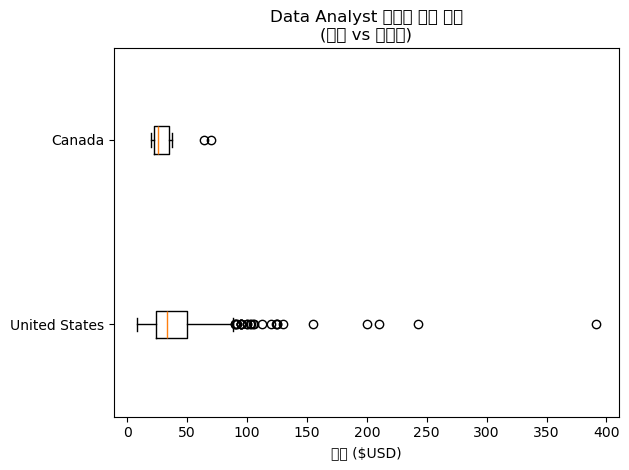

In [16]:
countries = ['United States', 'Canada']

df_DA_countries = df[(df['job_title_short'] == 'Data Analyst') &
                     (df['job_country'].isin(countries)) &
                     (df['salary_hour_avg'].notna())].copy()

country_list = [df_DA_countries[df_DA_countries['job_country'] == country]['salary_hour_avg']
    for country in countries
]

plt.boxplot(country_list, labels = countries, vert = False)

plt.title('Data Analyst 국가별 시급 비교\n(미국 vs 캐나다)')
plt.xlabel('시급 ($USD)')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))

plt.tight_layout()  # 레이아웃 자동 정리
plt.show()

C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\4059258771.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels = job_titles, vert = False)
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\4059258771.py:24: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\4059258771.py:24: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\4059258771.py:24: UserWarning: Glyph 52880 (\N{HANGUL SYLLABLE KAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 레이아웃 자동 정리
C:\Users\yhk25\AppData\Local\Temp\ipykernel_18580\4059258771.py:24: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) Deja

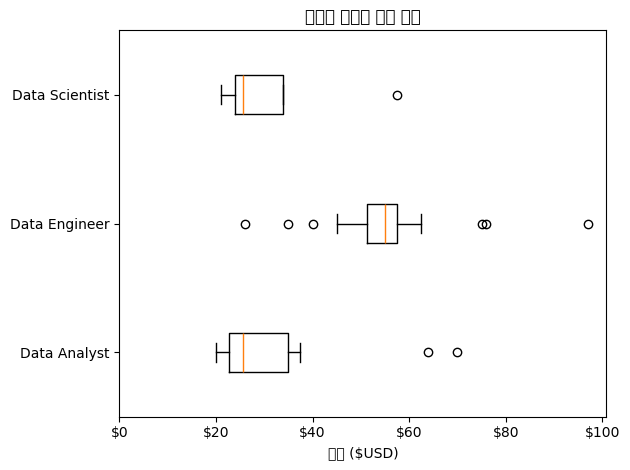

In [17]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_Canada = df[
    (df['job_title_short'].isin(job_titles)) &  # 위 3개 직무 중 하나인 행만
    (df['job_country'] == 'Canada') &           # 캐나다 데이터만
    (df['salary_hour_avg'].notna())             # 시급 데이터 있는 행만
].copy()

job_list = [
    df_Canada[df_Canada['job_title_short'] == job]['salary_hour_avg']
    for job in job_titles
]

plt.boxplot(job_list, labels = job_titles, vert = False)

plt.title('캐나다 직무별 시급 비교')
plt.xlabel('시급 ($USD)')

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x)}')
)

plt.xlim(left=0)   # x축 시작을 0으로 고정 (음수 방지)
plt.tight_layout() # 레이아웃 자동 정리
plt.show()